In [1]:
import pandas as pd
import numpy as np
import time 
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, f1_score, ConfusionMatrixDisplay, mean_absolute_error
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
mental_data = 'Teen_Mental_Health_Dataset.csv'

df = pd.read_csv(mental_data)

df.head(10)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


In [3]:

print(f"Dataset Size : {df.size} ")
print(f"Reading null data {df.isnull().sum().max()}")

Dataset Size : 15600 
Reading null data 0


<function matplotlib.pyplot.show(close=None, block=None)>

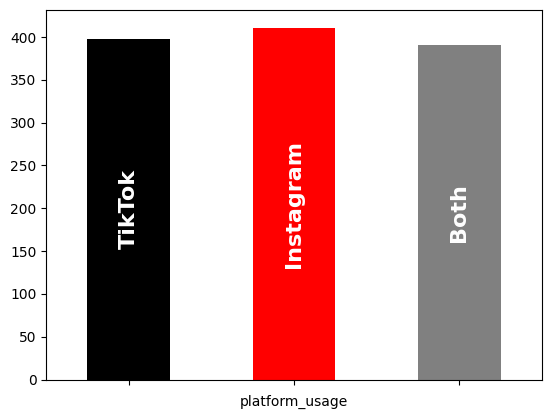

In [4]:
label = ['TikTok', 'Instagram', 'Both']

filtered_label = df['platform_usage'].value_counts().reindex(label).plot.bar(color=['black', 'red', 'gray'])
filtered_label.bar_label(filtered_label.containers[0], labels=label, label_type='center', color='white', rotation=90, fontsize=16, fontweight='bold')

filtered_label.set_xticklabels([])

plt.show

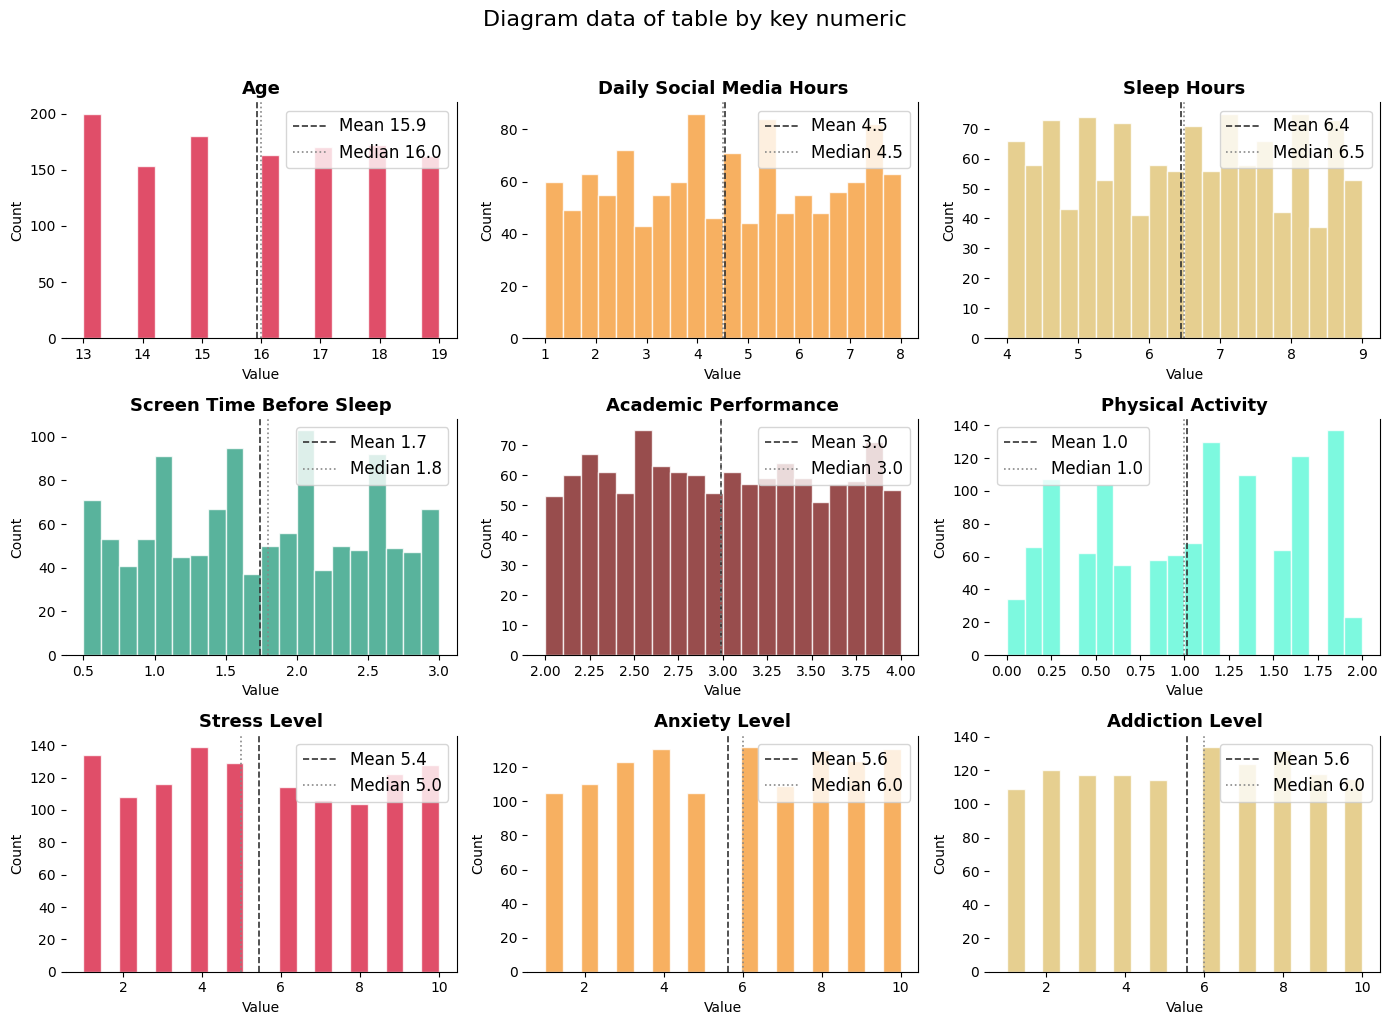

In [5]:
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.left': False,
    'axes.titlesize': 13, 'axes.titleweight' : 600
})
num_cols = ["age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep", 
            "academic_performance", "physical_activity", "stress_level", "anxiety_level", "addiction_level"]

colors_diagram = ['#D92243', '#F69D39', '#E0C375', '#2FA084', '#7F2020', '#5DF8D8']

fig, axes = plt.subplots(3, 3, figsize=(14,10))

fig.suptitle("Diagram data of table by key numeric", fontsize=16, y=1.02)

for i, filtered_label in enumerate(axes.flatten()):
    col = num_cols[i]
    data = df[col].dropna()
    filtered_label.hist(data, bins=20, color=colors_diagram[i % len(colors_diagram)], edgecolor='white', alpha=0.8)

    filtered_label.axvline(data.mean(), color='#333333', ls='--', lw=1.2, label=f"Mean {data.mean():.1f}")
    filtered_label.axvline(data.median(), color='#888888', ls=':', lw=1.2, label=f"Median {data.median():.1f}")

    filtered_label.set(title=col.replace('_',' ').title(), xlabel='Value', ylabel='Count')
    filtered_label.legend(fontsize=12)

plt.tight_layout()
plt.savefig("chart1_distributions.png", bbox_inches="tight")
plt.show()

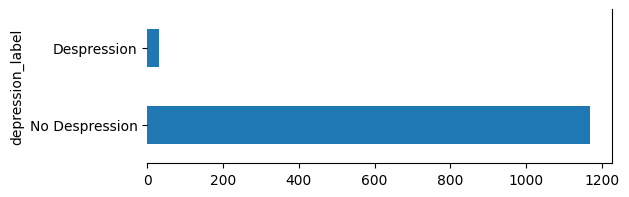

depression_label
0    1169
1      31
Name: count, dtype: int64


In [6]:
strlbl = 'depression_label'
plt.figure(figsize=(6, 2))

df[strlbl].value_counts().rename(index={1: 'Despression', 0: 'No Despression'}).plot.barh()

plt.show()

print(df[strlbl].value_counts())

In [7]:
df.dtypes

age                           int64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

In [8]:
print(df['social_interaction_level'].unique())
print(df['platform_usage'].unique())

<StringArray>
['low', 'high', 'medium']
Length: 3, dtype: str
<StringArray>
['Instagram', 'TikTok', 'Both']
Length: 3, dtype: str


# Preprocessing Steps
# Getting an missing values
# Converting String to Number

In [9]:
dfe=df.copy()
dfe['gender']=dfe['gender'].map({'male':1,'female':0})
dfe['social_interaction_level']=dfe['social_interaction_level'].map({'low':0, 'high':1, 'medium':2})
dfe['platform_usage']=dfe['platform_usage'].map({'Instagram':0 ,'TikTok':1, 'Both':2})

print(dfe.isnull().sum().max(), ', if 0 there is no null')

0 , if 0 there is no null


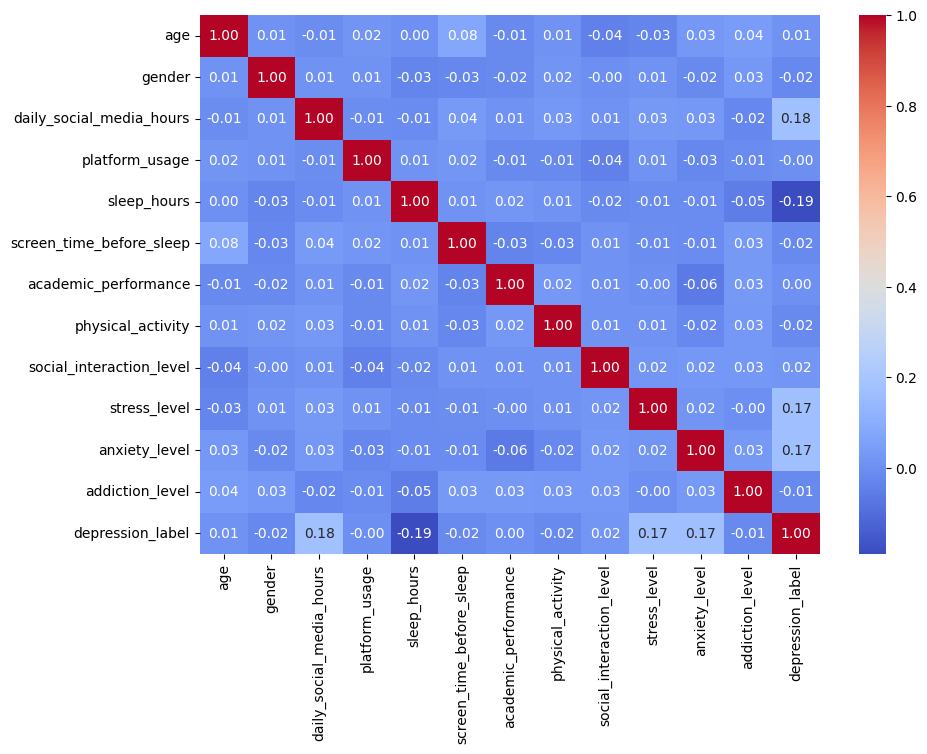

In [10]:
plt.figure(figsize=(10, 7))

sns.heatmap(dfe.corr(), annot=True, cmap='coolwarm', fmt='.2f') 

plt.show()

In [11]:
Feature = dfe.drop([strlbl], axis=1)
Label = dfe[strlbl]

print(f"Len of data : {Label.count()}")

Len of data : 1200


Split testing for training data 
* Select size of training
* Select size ot testing

In [12]:
X_train, X_valid, y_train, y_valid = train_test_split(Feature, Label, test_size=0.2, random_state=42, stratify=Label)

print("X train size : ", len(y_train)) 
print("y test size : ", len(y_valid))

print("\nLabel test count data")
print(y_valid.value_counts())
print("Length of data", len(y_valid))


X train size :  960
y test size :  240

Label test count data
depression_label
0    234
1      6
Name: count, dtype: int64
Length of data 240


In [13]:
print(f"The training data before smote : {len(y_train)}")

smote = SMOTETomek(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("The train after balanced with smote : ", len(y_train_smote))

The training data before smote : 960
The train after balanced with smote :  1870


Training model using 3 Type model 
* Decission Tree 
* Random Forest
* XGBoost

In [14]:
start_time = time.perf_counter()

model_dt = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_split=50, min_samples_leaf=35)

model_dt.fit(X_train_smote, y_train_smote)

train_predictions = model_dt.predict(X_train_smote)
test_predictions = model_dt.predict(X_valid)

print("The Train MAE of DT model : ", mean_absolute_error(y_train_smote, train_predictions))
print("The Test MAE of DT model : ", mean_absolute_error(y_valid, test_predictions))

The Train MAE of DT model :  0.0053475935828877
The Test MAE of DT model :  0.008333333333333333


Time  =  0.03 seconds


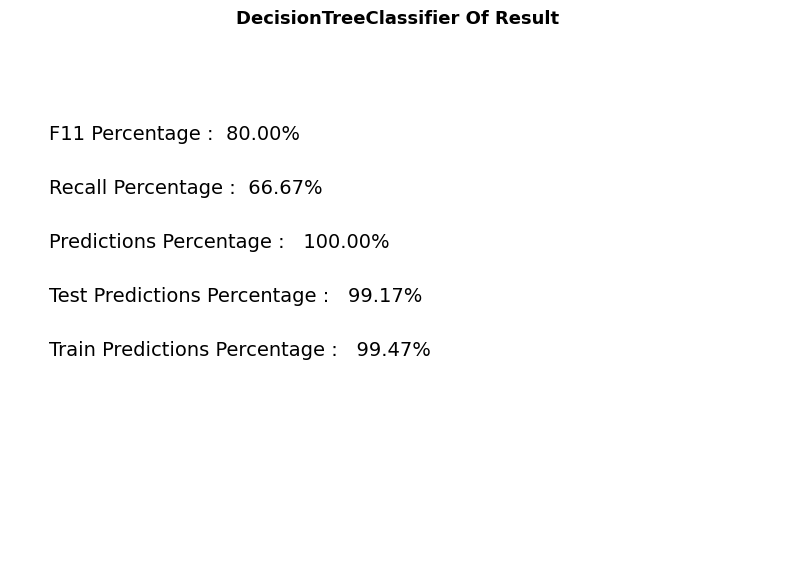

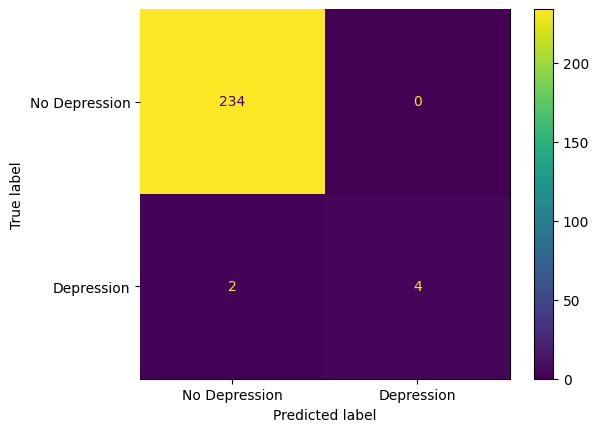

In [15]:
train_accuracy = accuracy_score(y_train_smote, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions )
Predictions = precision_score(y_valid, test_predictions)
F11 = f1_score(y_valid, test_predictions)
cm = confusion_matrix(y_valid, test_predictions)

print("Time  = ", format(time.perf_counter() -  start_time, '.2f'), 'seconds')

# Printing result

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("DecisionTreeClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Predictions * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Depression', 'Depression']).plot()

plt.show()

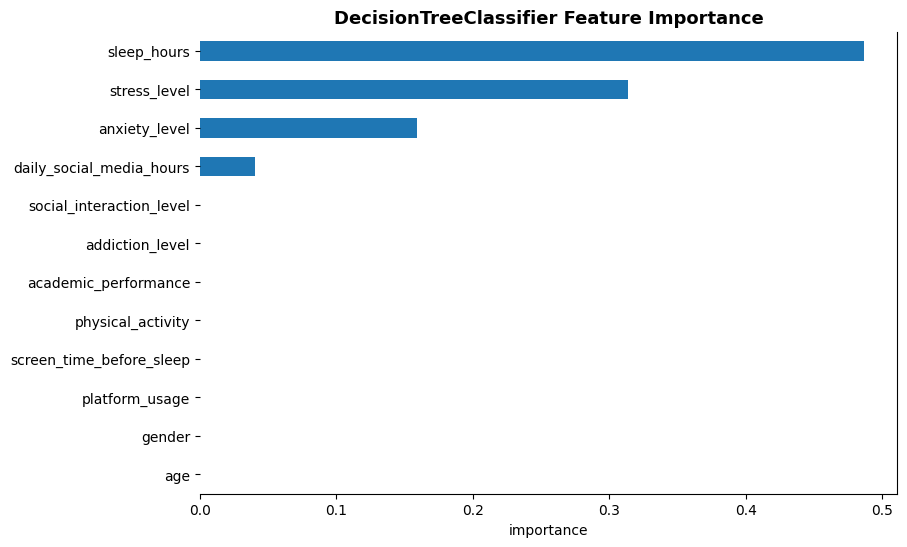

In [16]:
pd.Series(model_dt.feature_importances_, index=X_train.columns).sort_values().plot.barh(
    figsize=(9,6), title="DecisionTreeClassifier Feature Importance", xlabel = 'importance'

)

plt.show()


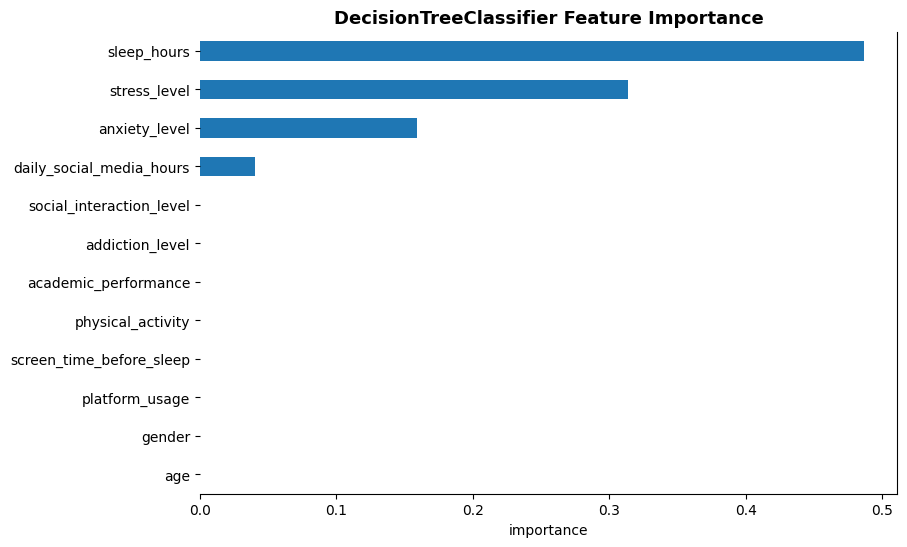

In [17]:
pd.Series(model_dt.feature_importances_, index=X_train.columns).sort_values().plot.barh(
    figsize=(9,6), title="DecisionTreeClassifier Feature Importance", xlabel = 'importance'
)

plt.show()

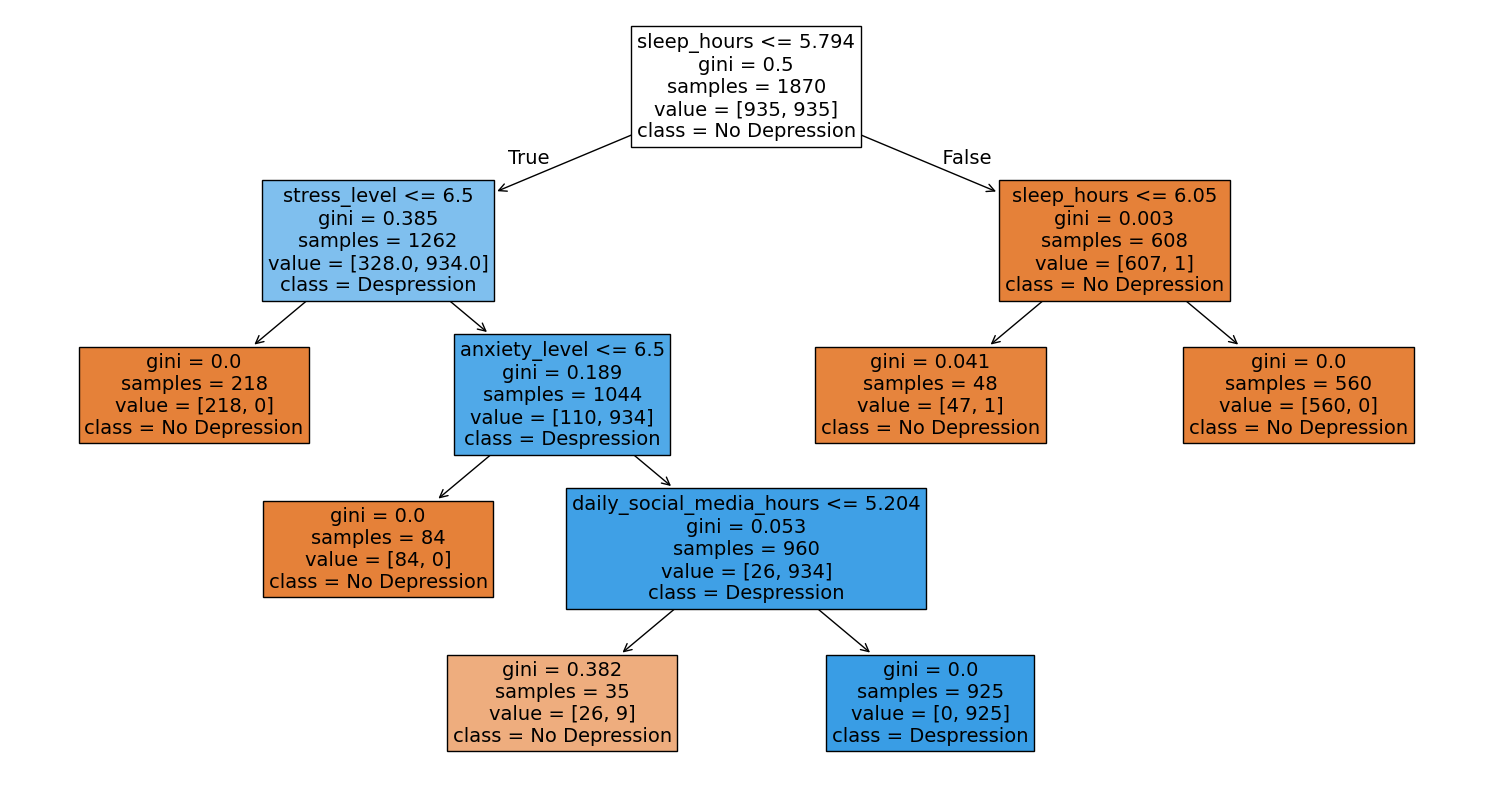

In [18]:
plt.figure(figsize=(19,10))
plot_tree(model_dt, max_depth=5, feature_names=X_train.columns, 
          class_names=['No Depression', 'Despression'], filled=True, rounded=False, fontsize=14)

plt.show()

New train of model set using Random Forest
* To Train Model 
* To Predict an answer
* Checking Score of Model Predictions
* Displat the Confusion Matrix

Time  =  0.26 seconds


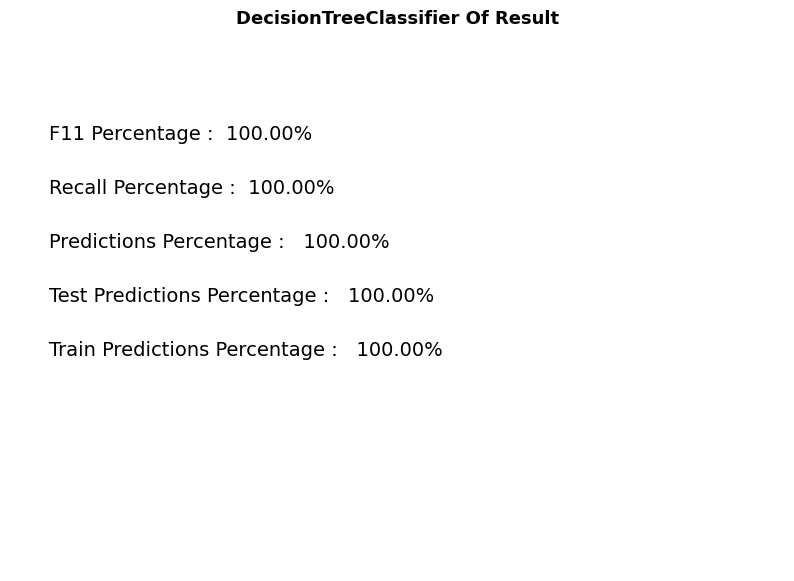

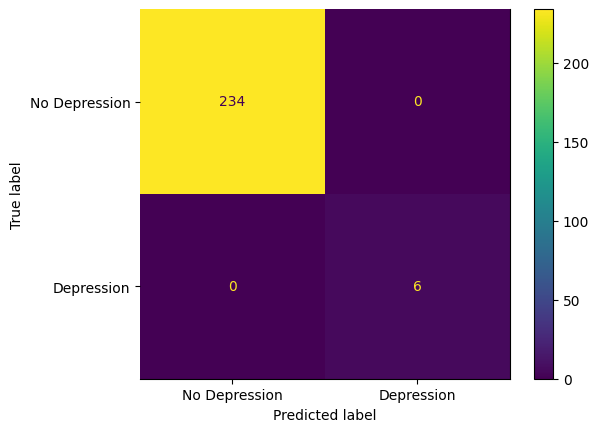

In [19]:
start_time = time.perf_counter()

modelXGB = XGBClassifier(n_estimators=500, learning_rate=0.01, max_depth=10, gamma=0.1, n_jobs=-1, random_state=42)

modelXGB.fit(X_train, y_train)

train_predictions = modelXGB.predict(X_train)
test_predictions = modelXGB.predict(X_valid)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions )
Predictions = precision_score(y_valid, test_predictions)
F11 = f1_score(y_valid, test_predictions)
cm = confusion_matrix(y_valid, test_predictions)

print("Time  = ", format(time.perf_counter() -  start_time, '.2f'), 'seconds')

# Printing result

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("DecisionTreeClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')

plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Predictions * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Depression', 'Depression']).plot()

plt.show()

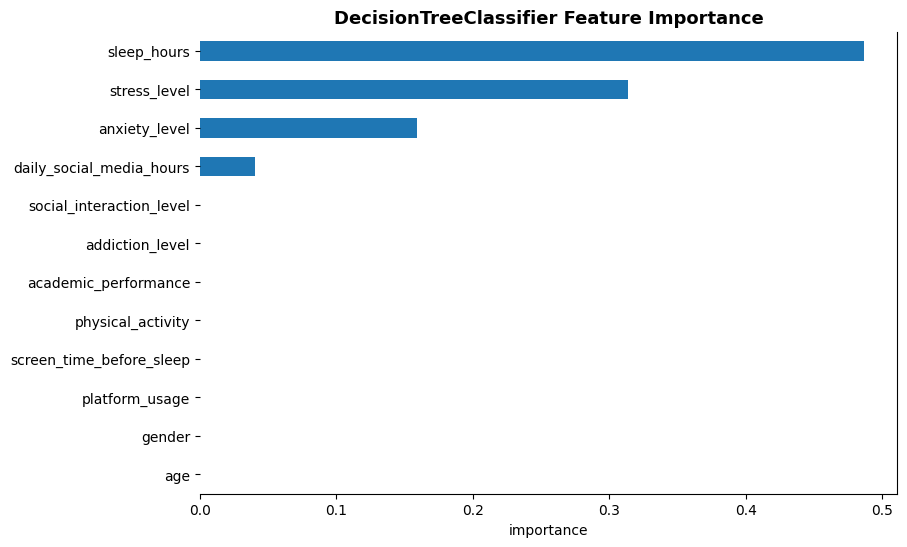

In [20]:
pd.Series(model_dt.feature_importances_, index=X_train.columns).sort_values().plot.barh(
    figsize=(9,6), title="DecisionTreeClassifier Feature Importance", xlabel = 'importance'
)

plt.show()

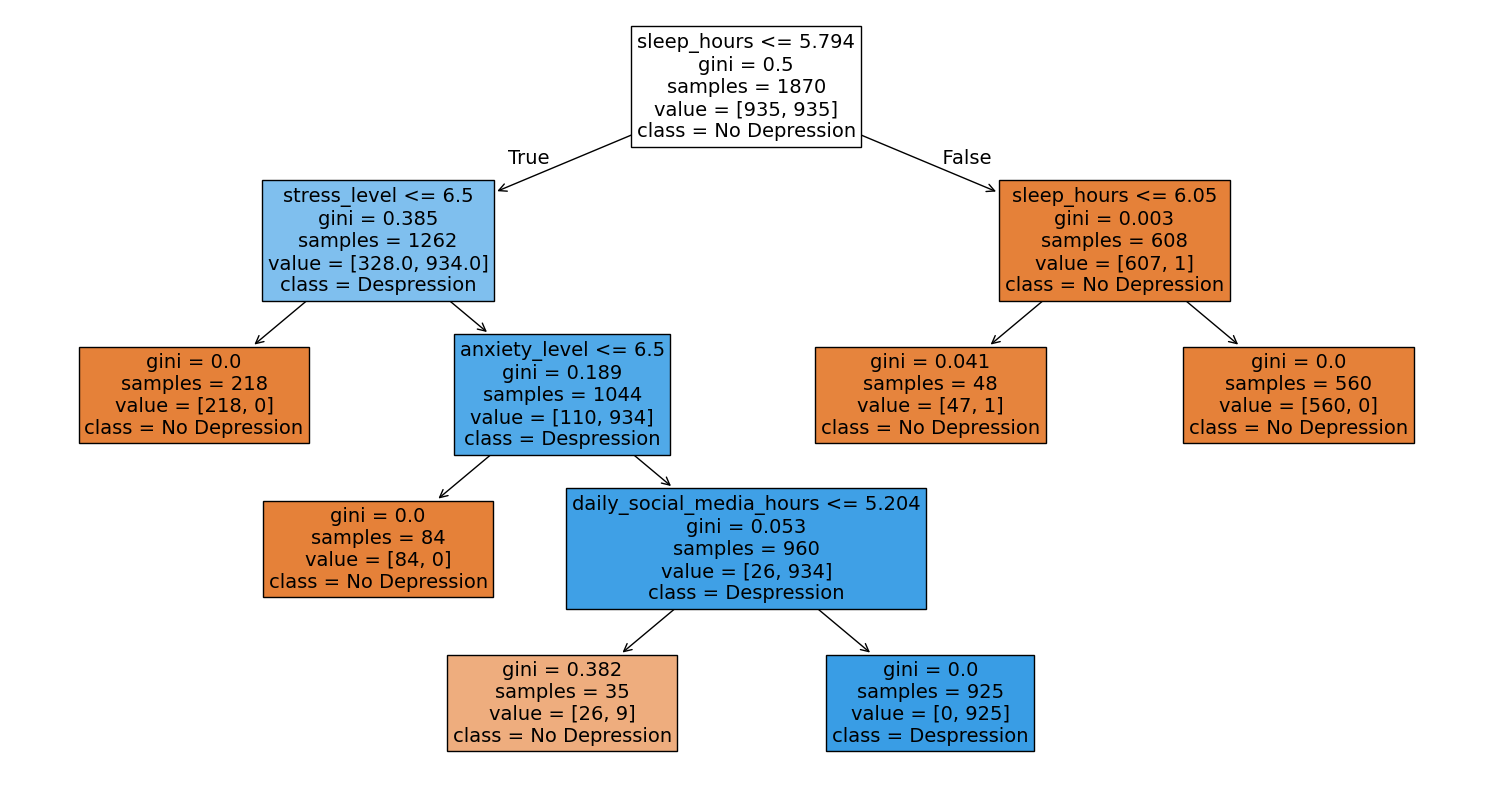

In [21]:
plt.figure(figsize=(19,10))
plot_tree(model_dt, max_depth=5, feature_names=X_train.columns, 
          class_names=['No Depression', 'Despression'], filled=True, rounded=False, fontsize=14)

plt.show()

Training Model Using Random Forest Classifier
* To Train Model
* Get Prediction answers
* Get the accuracy of the answers

Time  =  0.15 seconds


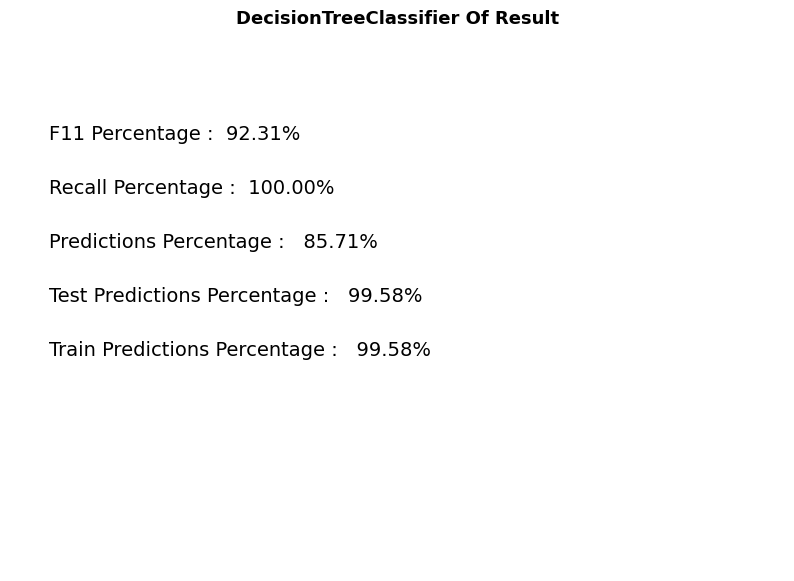

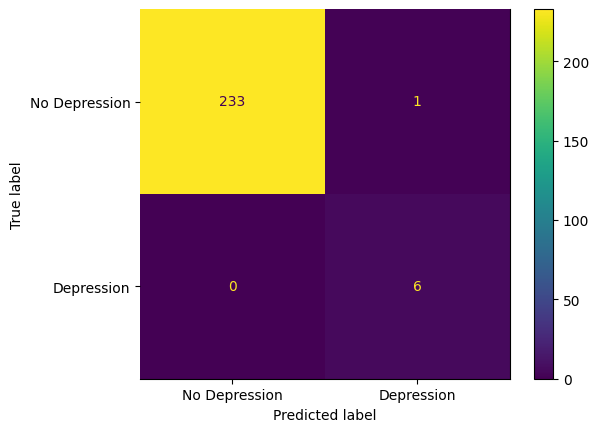

In [22]:
start_time = time.perf_counter()

modelRFS = RandomForestClassifier(n_estimators=100, n_jobs=1, max_depth=3, max_features='sqrt', random_state=42)

modelRFS.fit(X_train_smote, y_train_smote)

train_predictions = modelRFS.predict(X_train)
test_predictions = modelRFS.predict(X_valid)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_valid, test_predictions)

Recall = recall_score(y_valid, test_predictions )
Predictions = precision_score(y_valid, test_predictions)
F11 = f1_score(y_valid, test_predictions)
cm = confusion_matrix(y_valid, test_predictions)

print("Time  = ", format(time.perf_counter() -  start_time, '.2f'), 'seconds')

# Printing result

plt.figure(figsize=(10,7))
plt.axis('off')
plt.title("DecisionTreeClassifier Of Result")

plt.text(0.05, 0.80, f"F11 Percentage : {F11 * 100 : .2f}%", fontsize = 14, ha='left')

plt.text(0.05, 0.70, f"Recall Percentage : {Recall * 100 : .2f}%", fontsize = 14, ha='left')
plt.text(0.05, 0.60, f"Predictions Percentage :  {Predictions * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.50, f"Test Predictions Percentage :  {test_accuracy * 100 : .2f}%", fontsize=14, ha='left')
plt.text(0.05, 0.40, f"Train Predictions Percentage :  {train_accuracy * 100 : .2f}%", fontsize=14, ha='left')

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Depression', 'Depression']).plot()

plt.show()